# MNIST Image Classification Assignment

## Objective
This assignment develops and evaluates machine learning models for handwritten digit recognition using the MNIST dataset. The work covers the full classification pipeline, including data loading, preprocessing, model training, performance evaluation, hyperparameter tuning, and interpretation of results.

## Scope of the Work
The analysis focuses on classical machine learning methods for multiclass image classification. The notebook includes:

- loading the MNIST dataset
- visualizing representative digit images
- preparing the data for model training
- training classification models for digit recognition
- evaluating model performance using accuracy and confusion matrices
- improving performance through hyperparameter tuning
- analyzing prediction results and common misclassification patterns

The goal is not only to obtain strong predictive performance, but also to examine how model choice and preprocessing affect classification accuracy on handwritten digits.

# 1. Setup

This section prepares the working environment for the analysis. It imports the libraries needed for data handling, visualization, model training, and evaluation, sets a fixed random seed to support reproducibility, and defines a small helper function for saving figures generated throughout the notebook.

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification_assignment"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


# 2. Data Preparation

The **MNIST dataset** consists of grayscale images of handwritten digits, where each image is represented by **784 pixel values** arranged in a **28 × 28** format. In this section, the dataset is loaded, the target labels are converted into an appropriate numeric type, and the data is separated into **training** and **testing** sets. The **training set** is used to build the classification models, while the **test set** is reserved for evaluating how effectively the models generalize to unseen digit images.

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
X, y = mnist["data"], mnist["target"]
X.shape, y.shape


((70000, 784), (70000,))

In [5]:
# Convert target labels to integer format for classification
y = y.astype(np.uint8)
y[:10]


array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

## 2.1 Visualize a sample digit


Saving figure some_digit_plot


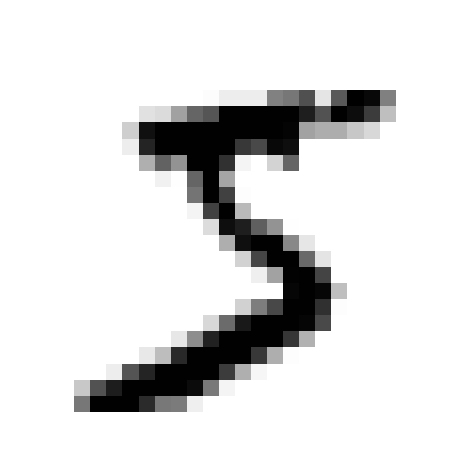

Label of the first image: 5


In [6]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
save_fig("some_digit_plot")
plt.show()

print("Label of the first image:", y[0])


## 2.2 Helper functions for plotting digits


In [7]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.binary, interpolation="nearest")
    plt.axis("off")

# EXTRA
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)

    # This is equivalent to n_rows = ceil(len(instances) / images_per_row)
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate(
        [instances, np.zeros((n_empty, size * size))], axis=0
    )

    # Reshape the array so it's organized as a grid containing 28x28 images
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes to build one large image
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(
        n_rows * size, images_per_row * size
    )

    plt.imshow(big_image, cmap=mpl.cm.binary, **options)
    plt.axis("off")


## 2.3 Visualize a grid of sample images


Saving figure more_digits_plot


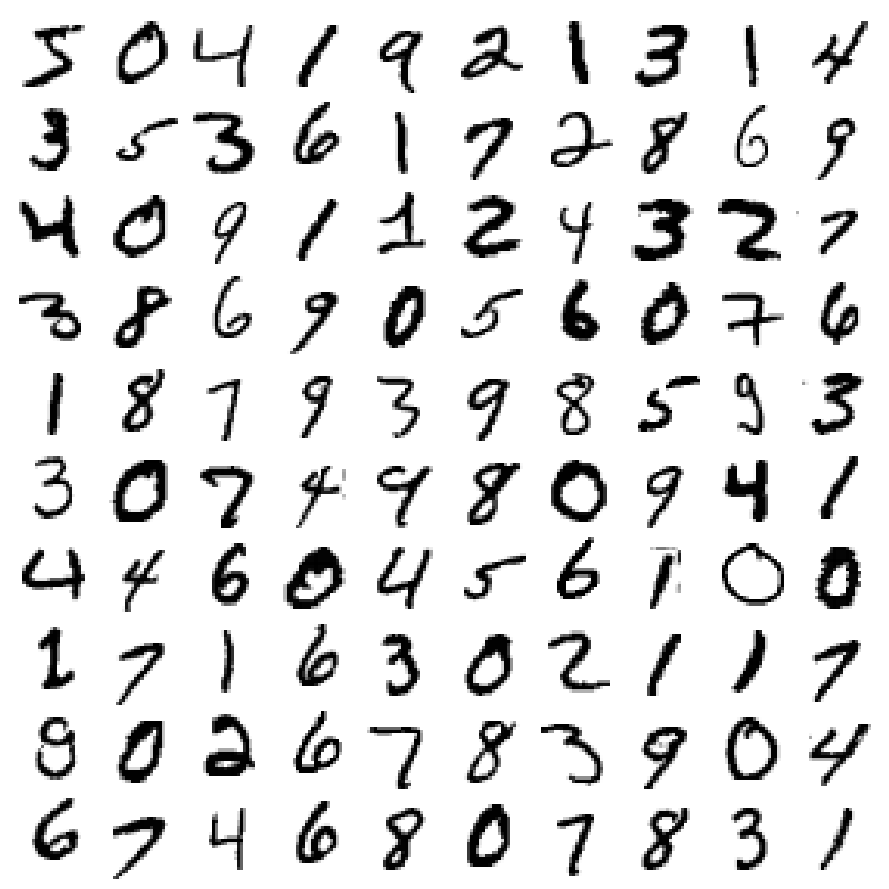

In [8]:
plt.figure(figsize=(9, 9))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
save_fig("more_digits_plot")
plt.show()


## 2.4 Split the dataset into training and testing sets


In [9]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((60000, 784), (10000, 784), (60000,), (10000,))

# 3. Data Preprocessing

Before training the models, the data is prepared in a form suitable for both **visual interpretation** and **classification**. Although each MNIST image is stored as a flattened vector of **784 features**, the original **28 × 28** structure is restored when displaying sample digits. For model training, feature scaling is applied where appropriate to place the input values on a more consistent numerical scale, which helps improve the performance of distance- and gradient-based methods such as the **SGDClassifier**.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
X_test_scaled = scaler.transform(X_test.astype(np.float64))

X_train_scaled.shape, X_test_scaled.shape


((60000, 784), (10000, 784))

# 4. Classification Model: Baseline Multiclass Classifier with SGD

As an initial approach, a **multiclass classification model** is built using **SGDClassifier**. This model serves as the **baseline** for the assignment and provides a reference point for evaluating later improvements. Establishing a baseline is important because it allows the performance of more refined models to be assessed in a clear and meaningful way.

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train, y_train)

print("Prediction for the first digit:", sgd_clf.predict([some_digit])[0])
print("True label:", y[0])


Prediction for the first digit: 3
True label: 5


## 4.1 Cross-validation accuracy before and after scaling


In [12]:
from sklearn.model_selection import cross_val_score

sgd_cv_scores_unscaled = cross_val_score(
    sgd_clf, X_train, y_train, cv=3, scoring="accuracy"
)

sgd_cv_scores_scaled = cross_val_score(
    sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy"
)

print("SGD cross-validation accuracy (unscaled):", sgd_cv_scores_unscaled)
print("Mean unscaled accuracy:", sgd_cv_scores_unscaled.mean())

print("\nSGD cross-validation accuracy (scaled):", sgd_cv_scores_scaled)
print("Mean scaled accuracy:", sgd_cv_scores_scaled.mean())


SGD cross-validation accuracy (unscaled): [0.87365 0.85835 0.8689 ]
Mean unscaled accuracy: 0.8669666666666668

SGD cross-validation accuracy (scaled): [0.8983 0.891  0.9018]
Mean scaled accuracy: 0.8970333333333333


## 4.2 Final SGD evaluation on the test set


In [13]:
from sklearn.metrics import accuracy_score

sgd_clf.fit(X_train_scaled, y_train)
y_test_pred_sgd = sgd_clf.predict(X_test_scaled)

sgd_test_accuracy = accuracy_score(y_test, y_test_pred_sgd)
print("SGD test accuracy (scaled):", sgd_test_accuracy)


SGD test accuracy (scaled): 0.8933


## 4.3 Confusion Matrix for the SGD Classifier

### Discussion

The **normalized confusion matrix** gives a clearer view of the classifier’s weaknesses than overall accuracy alone because it shows **where the errors are concentrated across classes**. Instead of treating all mistakes as equally important, it reveals which digit pairs are confused most often and therefore provides a more detailed picture of model behaviour.

Using the normalized form is appropriate here because it allows each class to be examined relative to its own number of examples. This makes the comparison more meaningful than relying only on raw counts, especially when the goal is to identify which digits are consistently difficult for the model.

In this case, the error pattern is not random. Several digits are frequently predicted as **8**, including **5 → 8 (535 cases)**, **3 → 8 (403)**, **2 → 8 (378)**, **9 → 8 (371)**, and **4 → 8 (347)**. This suggests that the **SGDClassifier** struggles most when different digits share dense strokes, loops, or rounded shapes that resemble the visual structure of an 8.

This interpretation is important because it shows the limitation of the baseline model more precisely. Although scaling improved the classifier, the confusion matrix indicates that the model still has difficulty separating classes when handwritten forms overlap in shape. The matrix therefore functions not only as an evaluation tool, but also as a method of **error analysis**.

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred_sgd = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx_sgd = confusion_matrix(y_train, y_train_pred_sgd)
conf_mx_sgd


array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

Saving figure sgd_confusion_matrix_plot


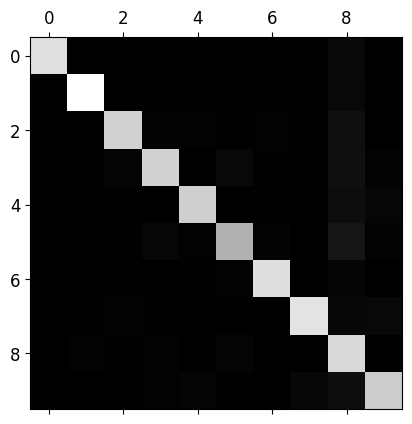

In [15]:
plt.matshow(conf_mx_sgd, cmap=plt.cm.gray)
save_fig("sgd_confusion_matrix_plot", tight_layout=False)
plt.show()


Saving figure sgd_confusion_matrix_errors_plot


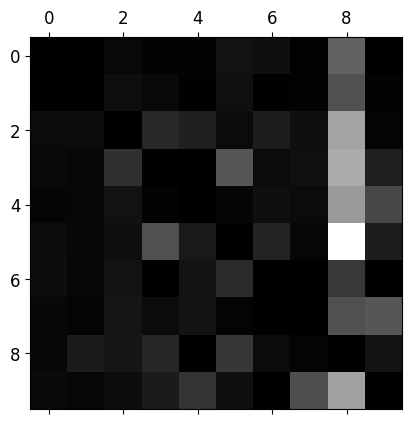

In [16]:
row_sums = conf_mx_sgd.sum(axis=1, keepdims=True)
norm_conf_mx_sgd = conf_mx_sgd / row_sums
np.fill_diagonal(norm_conf_mx_sgd, 0)

plt.matshow(norm_conf_mx_sgd, cmap=plt.cm.gray)
save_fig("sgd_confusion_matrix_errors_plot", tight_layout=False)
plt.show()


### Discussion

The **normalized confusion matrix** provides a more informative view of model performance than overall accuracy alone because it shows **how the errors are distributed across classes**. Rather than only indicating that the classifier makes mistakes, it reveals **which digits are mistaken for one another most often** and therefore highlights the specific weaknesses of the model.

Using the **normalized** form is an important decision in this analysis because the diagonal and off-diagonal values are easier to interpret on a **class-by-class basis**. This allows the performance for each digit to be examined relative to its own total number of examples, instead of being influenced mainly by raw counts. As a result, the matrix is more useful for identifying whether certain digits are consistently harder to distinguish.

In the visualization, the **diagonal cells** represent correct classifications, while the **off-diagonal cells** represent misclassifications. Brighter off-diagonal regions indicate digit pairs that the classifier confuses more frequently. These patterns are valuable because they help explain **why the model’s performance is limited**: errors often arise not randomly, but in cases where different handwritten digits share similar visual structures, stroke patterns, or ambiguous shapes.

For this reason, the confusion matrix is used here not simply as a reporting tool, but as an **error-analysis method**. It helps move the evaluation beyond a single performance score and supports a more precise interpretation of how the classifier behaves across the full set of digit classes.

# 5. Hyperparameter Tuning

Improving model performance requires more than selecting a suitable algorithm; it also depends on choosing **appropriate hyperparameter values**. In this section, the **KNeighborsClassifier** is refined through a structured tuning process using **GridSearchCV**, which systematically compares multiple parameter combinations under cross-validation.

The focus is placed on two hyperparameters that directly influence how KNN makes decisions:

- **`n_neighbors`** controls how many nearby training examples contribute to each prediction.
- **`weights`** determines whether all neighbors contribute equally or whether closer neighbors are given greater influence.

These choices are important because they affect the balance between **stability** and **sensitivity** in classification. A smaller number of neighbors may capture local patterns more precisely, while a slightly larger value can reduce sensitivity to noise. Similarly, distance-based weighting can improve predictions when the nearest examples are more informative than those farther away.

A grid-search procedure is used so that the selection of hyperparameters is based on **measured performance** rather than assumption. This makes the tuning process more rigorous and allows the final model to be justified through evidence. The selected parameter grid provides a focused comparison of reasonable alternatives while keeping the search interpretable and computationally practical for this assignment.


> **Runtime note:** The hyperparameter search in this section can require substantial computation because each candidate setting is evaluated repeatedly across cross-validation folds on a large training set. For that reason, this step is expected to take noticeably longer than the earlier training and evaluation stages.

## 5.1 Default KNN model (before tuning)


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_default = KNeighborsClassifier()
knn_default.fit(X_train, y_train)
y_test_pred_knn_default = knn_default.predict(X_test)

knn_default_accuracy = accuracy_score(y_test, y_test_pred_knn_default)
print("Default KNN test accuracy:", knn_default_accuracy)


Default KNN test accuracy: 0.9688


## 5.2 Grid search for the best KNN hyperparameters


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5, verbose=3)
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.972 total time=  40.6s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time=  39.8s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  40.6s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  39.6s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  43.4s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  40.4s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  40.0s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  41.0s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  39.5s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  38.8s
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.969 total time=  40.5s
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5],
                          'weights': ['uniform', 'distance']}],
             verbose=3)

In [19]:
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


Best hyperparameters: {'n_neighbors': 4, 'weights': 'distance'}
Best cross-validation score: 0.9716166666666666


## 5.3 Evaluate the tuned KNN model on the test set


In [20]:
best_knn = grid_search.best_estimator_
y_test_pred_knn = best_knn.predict(X_test)

knn_test_accuracy = accuracy_score(y_test, y_test_pred_knn)
print("Tuned KNN test accuracy:", knn_test_accuracy)
print("Accuracy gain over default KNN:", knn_test_accuracy - knn_default_accuracy)


Tuned KNN test accuracy: 0.9714
Accuracy gain over default KNN: 0.0026000000000000467


In [21]:
conf_mx_knn = confusion_matrix(y_test, y_test_pred_knn)
conf_mx_knn


array([[ 973,    1,    1,    0,    0,    1,    3,    1,    0,    0],
       [   0, 1132,    2,    0,    0,    0,    1,    0,    0,    0],
       [  10,    5,  995,    2,    1,    0,    0,   16,    3,    0],
       [   0,    1,    3,  974,    1,   14,    1,    7,    4,    5],
       [   1,    5,    0,    0,  950,    0,    4,    3,    0,   19],
       [   4,    0,    0,    9,    2,  862,    7,    1,    3,    4],
       [   4,    2,    0,    0,    3,    3,  946,    0,    0,    0],
       [   0,   17,    4,    0,    3,    0,    0,  994,    0,   10],
       [   5,    2,    4,   14,    5,   11,    4,    4,  920,    5],
       [   3,    4,    2,    7,    9,    4,    1,   10,    1,  968]])

Saving figure knn_confusion_matrix_plot


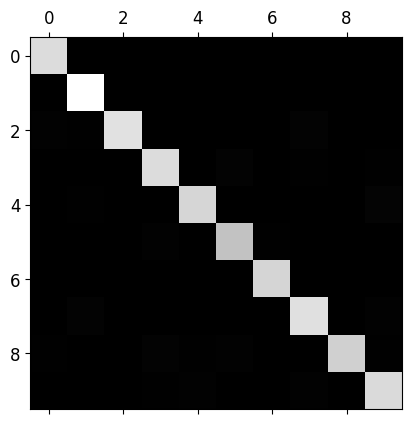

In [22]:
plt.matshow(conf_mx_knn, cmap=plt.cm.gray)
save_fig("knn_confusion_matrix_plot", tight_layout=False)
plt.show()


### Discussion

The tuned **KNN model** performed better than the baseline **SGD classifier** on this task. In the final evaluation, the tuned KNN model achieved a **test accuracy of 0.9714**, compared with **0.8933** for the scaled SGD model and **0.9688** for the default KNN model.

This result suggests that **model choice** had a greater effect on performance than hyperparameter tuning alone. Moving from a linear classifier to a similarity-based method produced a substantial improvement, while tuning the KNN model provided a smaller but still measurable gain over the default configuration.

The difference is meaningful from a modelling perspective. KNN makes predictions by comparing each test image with nearby training examples, which makes it well suited to handwritten digit recognition, where local stroke patterns and pixel-level similarity are highly informative. In contrast, the **SGD classifier** offers a faster linear baseline, but it is less flexible when the class boundaries are shaped by fine visual variation.

For this reason, the comparison between the two models is useful not only in terms of accuracy, but also in understanding how different classification strategies respond to image-based data. The final result shows that the tuned KNN classifier is better able to capture the local structure of handwritten digits in the MNIST dataset.

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred_knn, digits=4))

              precision    recall  f1-score   support

           0     0.9730    0.9929    0.9828       980
           1     0.9683    0.9974    0.9826      1135
           2     0.9842    0.9641    0.9741      1032
           3     0.9682    0.9644    0.9663      1010
           4     0.9754    0.9674    0.9714       982
           5     0.9631    0.9664    0.9647       892
           6     0.9783    0.9875    0.9829       958
           7     0.9595    0.9669    0.9632      1028
           8     0.9882    0.9446    0.9659       974
           9     0.9575    0.9594    0.9584      1009

    accuracy                         0.9714     10000
   macro avg     0.9716    0.9711    0.9712     10000
weighted avg     0.9715    0.9714    0.9714     10000



The classification report complements the confusion matrix by showing **precision, recall, and F1-score** for each digit class. This makes it possible to identify not only the overall strength of the model, but also which classes remain relatively more difficult. In this assignment, the report confirms that performance is strong across all classes, while some digits with greater visual ambiguity still show slightly lower recall than others.

# 6. Visualization of Predictions

To evaluate the model beyond numerical performance measures, it is important to inspect **individual prediction outcomes** directly. In this section, a random sample of **test images** is displayed together with their **true labels** and the model’s **predicted labels**. This makes it possible to assess not only whether the classifier is accurate overall, but also how it behaves on specific handwritten digits.

This form of visualization is useful because it links the model’s decisions to the actual image content. Correct predictions help illustrate the kinds of digit patterns the classifier handles reliably, while incorrect predictions reveal cases where handwriting is ambiguous, distorted, or visually similar to another class. As a result, the prediction plots support a more detailed interpretation of model behaviour than summary metrics alone.

Saving figure random_test_predictions


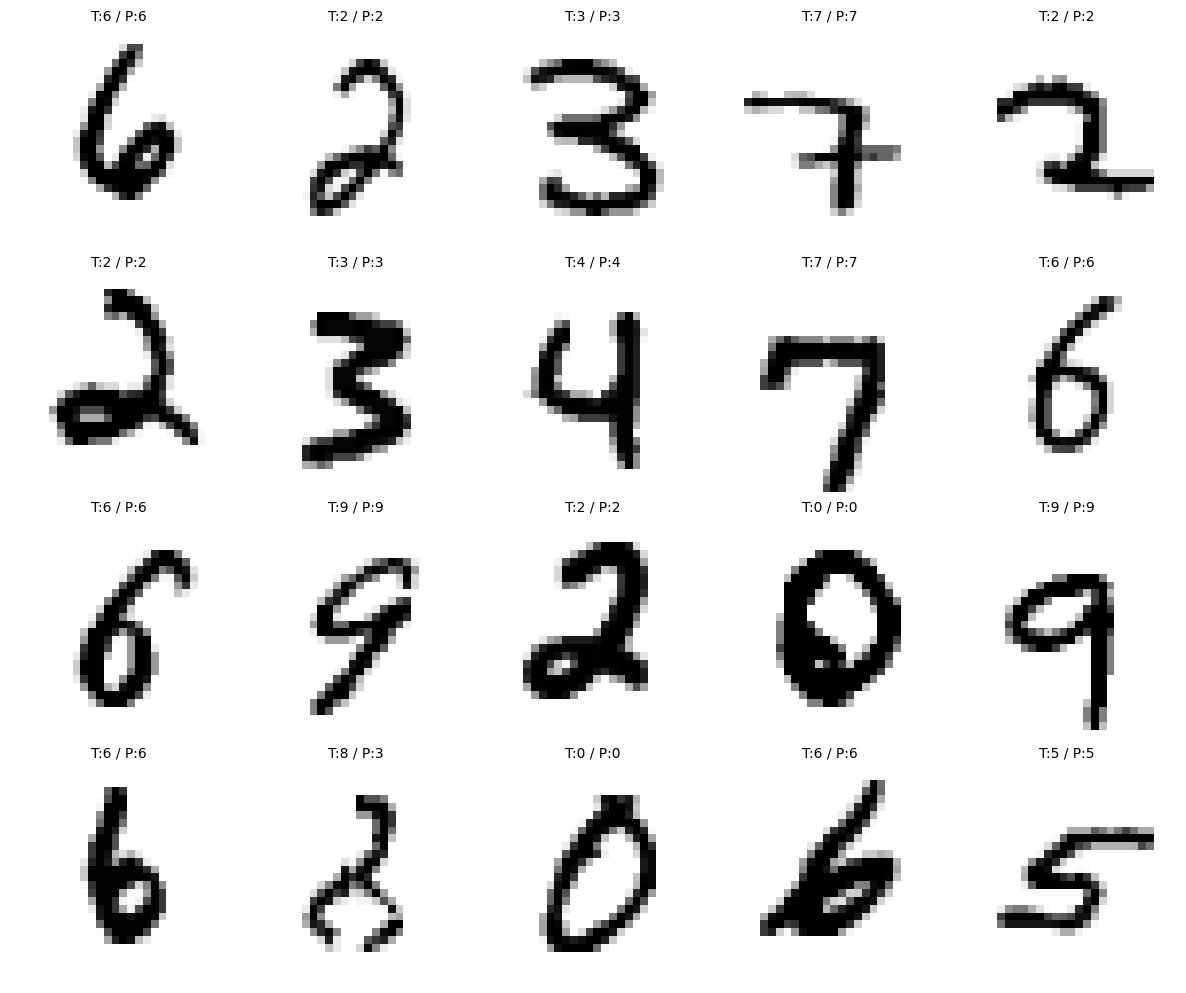

In [24]:
random_test_idx = np.random.permutation(len(X_test))[:20]

plt.figure(figsize=(12, 10))
for plot_index, image_index in enumerate(random_test_idx):
    plt.subplot(4, 5, plot_index + 1)
    plt.imshow(X_test[image_index].reshape(28, 28), cmap=mpl.cm.binary)
    plt.title(f"T:{y_test[image_index]} / P:{y_test_pred_knn[image_index]}", fontsize=10)
    plt.axis("off")

save_fig("random_test_predictions")
plt.show()


### Interpretation of Random Test Predictions

The random test sample provides a useful visual check on the behaviour of the tuned **KNN model**. In this set of examples, most predictions match the true labels, which is consistent with the model’s overall test accuracy of **0.9714**. The sample therefore supports the conclusion that the classifier performs reliably on a wide range of handwritten styles.

At the same time, the plot also shows that the remaining errors are concentrated in visually ambiguous cases rather than in clearly written digits. For example, one image with true label **8** is predicted as **3**, which is understandable because its upper and lower curves are not fully closed and the shape resembles a handwritten 3. This is important because it shows that the model’s mistakes are generally linked to **visual ambiguity**, not to widespread failure across the test set.

# 7. Error Analysis

A strong classification result should be evaluated not only by its overall accuracy, but also by the **pattern of its remaining errors**. For that reason, this section examines the misclassifications made by the tuned **KNN model** in a more focused way. Rather than treating all errors as equally informative, attention is directed to the **most frequent confusion pair** in the confusion matrix, since repeated confusion between the same two classes usually indicates a meaningful visual overlap between them.

This is an important analytical choice. Looking at the most common confusion pair helps identify whether the model’s mistakes are caused by random noise or by a consistent difficulty in separating two digit classes with similar handwritten forms. By visualizing examples from that confusion pair, the analysis can move beyond abstract counts and connect the model’s behaviour to the actual shape, stroke pattern, and ambiguity of the images themselves.

The purpose of this section is therefore to understand the **source of the model’s errors**, not simply to report that errors exist. This makes the evaluation more rigorous and provides clearer insight into the limitations of the classifier on difficult handwritten cases.

In [25]:
conf_pair_matrix = conf_mx_knn.copy()
np.fill_diagonal(conf_pair_matrix, 0)

flat_index = np.argmax(conf_pair_matrix)
cl_a, cl_b = np.unravel_index(flat_index, conf_pair_matrix.shape)

print("Most confused true/predicted pair:")
print("True digit:", cl_a)
print("Predicted as:", cl_b)
print("Number of such errors:", conf_pair_matrix[cl_a, cl_b])


Most confused true/predicted pair:
True digit: 4
Predicted as: 9
Number of such errors: 19


Saving figure knn_error_analysis_digits_plot


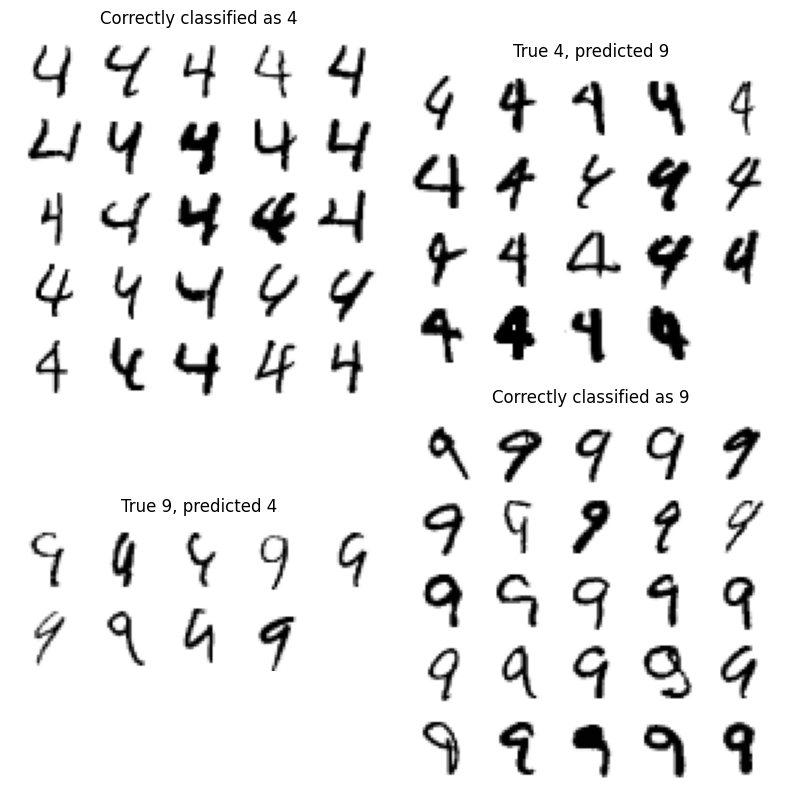

In [26]:
X_aa = X_test[(y_test == cl_a) & (y_test_pred_knn == cl_a)]
X_ab = X_test[(y_test == cl_a) & (y_test_pred_knn == cl_b)]
X_ba = X_test[(y_test == cl_b) & (y_test_pred_knn == cl_a)]
X_bb = X_test[(y_test == cl_b) & (y_test_pred_knn == cl_b)]

plt.figure(figsize=(8, 8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.title(f"Correctly classified as {cl_a}")

plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.title(f"True {cl_a}, predicted {cl_b}")

plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.title(f"True {cl_b}, predicted {cl_a}")

plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.title(f"Correctly classified as {cl_b}")

save_fig("knn_error_analysis_digits_plot")
plt.show()


### Interpretation of Challenging Cases

The most difficult cases do not necessarily indicate a fundamentally weak model. In many instances, they reflect the natural ambiguity of handwritten digits and the visual overlap that can exist between classes. The main reasons these cases are challenging include:

- **Irregular handwriting style**  
  Some digits are written in forms that differ noticeably from the standard or most recognizable pattern, making them harder to classify correctly.

- **Similarity in stroke structure**  
  Confusion often occurs when two digits share related visual features, such as curved strokes, closed loops, or similar line arrangements.

- **Incomplete or exaggerated pen marks**  
  Missing strokes, extra marks, or unusually heavy writing can alter the appearance of a digit enough to make it resemble another class.

- **Compression or distortion of shape**  
  When a digit is written too narrowly, too broadly, or with uneven proportions, its defining characteristics may become less clear.

- **Genuine visual ambiguity**  
  Some images are difficult even for a human reader to interpret confidently, which means occasional misclassification is understandable rather than surprising.

These patterns show that the remaining errors are **not random**. Instead, they are concentrated in cases where the visual boundary between classes becomes less distinct. This suggests that most misclassifications arise from **shape similarity and handwriting variability**, which are inherent challenges in handwritten-digit recognition.

# 8. Final Comparison and Conclusion


In [27]:
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"SGD mean CV accuracy (unscaled): {sgd_cv_scores_unscaled.mean():.4f}")
print(f"SGD mean CV accuracy (scaled):   {sgd_cv_scores_scaled.mean():.4f}")
print(f"SGD test accuracy (scaled):      {sgd_test_accuracy:.4f}")
print("-" * 70)
print(f"Default KNN test accuracy:       {knn_default_accuracy:.4f}")
print(f"Best KNN hyperparameters:        {grid_search.best_params_}")
print(f"Best KNN CV score:               {grid_search.best_score_:.4f}")
print(f"Tuned KNN test accuracy:         {knn_test_accuracy:.4f}")
print(f"Improvement over default KNN:    {knn_test_accuracy - knn_default_accuracy:.4f}")
print("=" * 70)


FINAL RESULTS SUMMARY
SGD mean CV accuracy (unscaled): 0.8670
SGD mean CV accuracy (scaled):   0.8970
SGD test accuracy (scaled):      0.8933
----------------------------------------------------------------------
Default KNN test accuracy:       0.9688
Best KNN hyperparameters:        {'n_neighbors': 4, 'weights': 'distance'}
Best KNN CV score:               0.9716
Tuned KNN test accuracy:         0.9714
Improvement over default KNN:    0.0026


## Conclusion and Reflection

This assignment demonstrates that the **MNIST dataset** can be classified effectively using **classical machine-learning methods** when the workflow is designed carefully. The results show that a clear sequence of **data preparation, preprocessing, model training, evaluation, and tuning** is sufficient to produce strong performance on handwritten digit recognition.

Several conclusions emerge from the analysis:

1. **Classical machine-learning models can perform strongly on handwritten digit classification**, even without deep-learning methods.
2. The **SGDClassifier** provided a useful baseline, and scaling improved its mean cross-validation accuracy from **0.8670** to **0.8970**.
3. The best-performing model was the tuned **KNeighborsClassifier**, which achieved a **test accuracy of 0.9714**, compared with **0.9688** for the default KNN model and **0.8933** for the scaled SGD model.
4. The improvement from hyperparameter tuning was relatively small compared with the improvement gained from selecting a more suitable model.
5. The remaining errors were concentrated in visually similar digit pairs, showing that most misclassifications were linked to handwriting ambiguity rather than widespread model weakness.

### Final Reflection
Overall, this assignment shows that effective image classification is not only a matter of achieving a high accuracy score, but also of understanding **how** and **why** a model makes its decisions. By comparing a baseline model with a tuned alternative, the analysis makes it possible to see the effect of both **model choice** and **parameter selection** on performance.

The final results indicate that handwritten digit recognition can be approached successfully with well-established machine-learning techniques, provided that the data is prepared carefully and the evaluation is interpreted thoughtfully. This makes the exercise valuable not only as a classification task, but also as an example of how to assess model behaviour in a structured and evidence-based way.